# SciPy Bootcamp — Week 1, Day 3E

##### Multiple Testing, Advanced Topics & Pitfalls
##### Multiple testing correction, Simpson’s Paradox, novelty effect, Bayesian A/B, A/A testing, chi-squared
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (Multiple testing correction): You run 15 simultaneous A/B tests. 12 have no real effect, 3 have true effects.
##### Q2 (Simpson’s Paradox): Build a synthetic dataset that demonstrates Simpson’s Paradox in an A/B test.
##### Q3 (Novelty effect detection): Simulate an A/B test running for 21 days where treatment gets a novelty bump.
##### Q4 (Bayesian A/B testing): Implement a Bayesian A/B test for the same data as Day 3A Q1.
##### Q5 (Full A/B testing audit): You are given a completed A/B test with multiple validity threats.
##### Q6 (Chi-squared test — categorical associations): The missing non-parametric test for categorical outcomes.
# (a) Theory: chi-squared independence vs goodness of fit, Cramer’s V effect size
# (b) Simulate a 3x2 contingency table: device type x conversion. Run stats.chi2_contingency.
# (c) Compute Cramer’s V as effect size.
# (d) Visualize observed vs expected counts as a side-by-side heatmap.
# (e) Multi-segment: run chi-squared across 10 segments, apply Bonferroni correction.


In [179]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Multiple testing correction

```
You run 15 simultaneous A/B tests. 12 have no real effect, 3 have true effects.
# Simulate p-values: 12 from Uniform(0,1) (null), 3 from Beta(1,8) (real effects, smaller p-values).
# (a) Plot the p-value distribution as a histogram. Can you visually distinguish null from real?
# (b) Apply Bonferroni correction. How many tests are significant?
# (c) Apply Benjamini-Hochberg FDR correction. How many tests are significant?
# (d) In a comment: when would you prefer Bonferroni over BH FDR?
```


In [180]:
# Q1: Multiple testing correction
# Chart + analysis woven together — visualize as you discover

In [181]:
# (a) Plot the p-value distribution as a histogram. Can you visually distinguish null from real?

# setup data
np.random.seed(420)

null_pvals = np.random.uniform(0,1,12) # no effect
print(null_pvals)

effect_pvals = np.random.beta(1,8,3) # with effect
print(effect_pvals)

pvals = np.concatenate([null_pvals, effect_pvals])
print(pvals)


[0.31564591 0.45303068 0.26698226 0.10892818 0.86816648 0.62972852
 0.35251871 0.0675376  0.62635059 0.59866086 0.09221725 0.05685155]
[0.02651833 0.06984508 0.14343636]
[0.31564591 0.45303068 0.26698226 0.10892818 0.86816648 0.62972852
 0.35251871 0.0675376  0.62635059 0.59866086 0.09221725 0.05685155
 0.02651833 0.06984508 0.14343636]


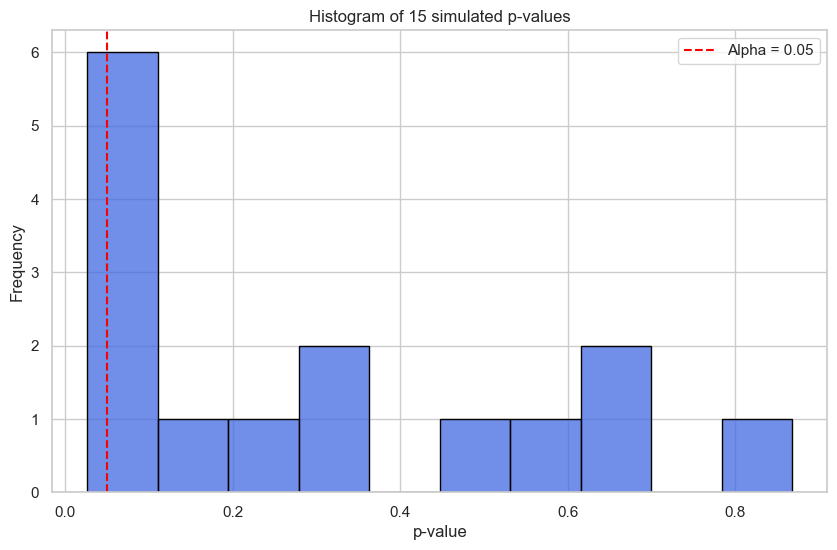

In [182]:
# plotting
plt.figure(figsize=(10,6))
sns.histplot(pvals, bins=10, color='royalblue', edgecolor='black')

plt.axvline(x=0.05, color='red', linestyle='--', label='Alpha = 0.05')

plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Histogram of 15 simulated p-values')

plt.legend()
plt.show()

# Yes, I can visually distinguish null from real

In [183]:
# (b) Apply Bonferroni correction. How many tests are significant?

from statsmodels.stats.multitest import multipletests

reject_bonf, p_bonf, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
print(f'After Bonferroni: {sum(reject_bonf)} significant')

After Bonferroni: 0 significant


In [186]:
# (c) Apply Benjamini-Hochberg FDR correction. How many tests are significant?
reject_bh, p_bh, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
print(f'After BH FDR:     {sum(reject_bh)} significant')


After BH FDR:     0 significant


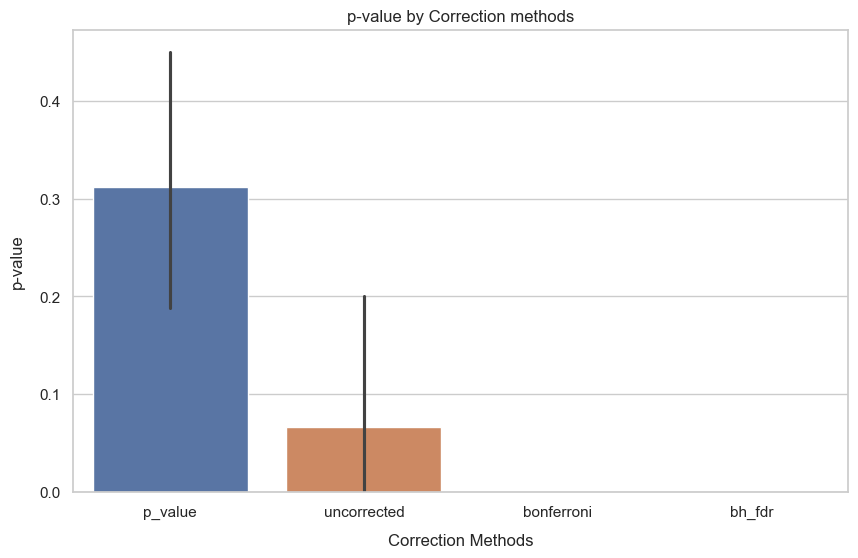

In [197]:
# Show which tests each method flags
results = pd.DataFrame({'p_value': pvals,
                        'uncorrected': pvals < 0.05,
                        'bonferroni': reject_bonf,
                        'bh_fdr': reject_bh})

results

plt.figure(figsize=(10,6))
sns.barplot(results)
plt.xlabel('Correction Methods', labelpad=10)
plt.ylabel('p-value', labelpad=10)
plt.title('p-value by Correction methods')
plt.show()
#results.sort_values('p_value').plot(kind='bar', y=['uncorrected','bonferroni','bh_fdr'])

In [34]:
# (d) In a comment: when would you prefer Bonferroni over BH FDR?

# Use Bonferroni when:
# 1. You have a very small number of tests (e.g., < 5).
# 2. The cost of a False Positive is catastrophic (e.g., medical safety trials, 
#    sending a rocket to space). You need to be 100% sure the effect is real.
# 3. You want to control the "Family-Wise Error Rate" (making ZERO mistakes total), 
#    whereas BH FDR only controls the "Proportion" of mistakes among your hits.

---

### Q2 — Simpson's Paradox

```
Build a synthetic dataset that demonstrates Simpson's Paradox in an A/B test.
# Setup: test a new mobile app feature. Control gets mostly mobile users, treatment gets mostly desktop.
# Mobile users convert at 8%, desktop users at 25%.
# Control: 8000 mobile + 2000 desktop. Treatment: 2000 mobile + 8000 desktop.
# (a) Compute overall conversion rate for control and treatment. Which looks better overall?
# (b) Compute conversion rate by segment (mobile/desktop). Which is actually better in BOTH segments?
# (c) Build a stacked bar chart showing the segment composition + conversion rates.
# (d) Write a 3-sentence explanation of what went wrong and how to avoid it in real experiments.
```


In [54]:
# Q2: Simpson's Paradox
# Chart + analysis woven together — visualize as you discover


In [44]:
# setup data

data = pd.DataFrame({
    'group'    : ['Control','Control','Treatment','Treatment'],
    'segment'  : ['Mobile', 'Desktop', 'Mobile', 'Desktop'],
    'users'    : [8000, 2000, 2000, 8000],
    'converted': [640,  500,  160,  2000],
})
data['rate'] = data['converted'] / data['users']
display(data)

,group,segment,users,converted,rate
0,Control,Mobile,8000,640,0.08
1,Control,Desktop,2000,500,0.25
2,Treatment,Mobile,2000,160,0.08
3,Treatment,Desktop,8000,2000,0.25


In [38]:
# (a) Compute overall conversion rate for control and treatment. Which looks better overall?
for group in ['Control', 'Treatment']:
    d = data[data['group'] == group]
    overall = d['converted'].sum() / d['users'].sum()
    print(f'{group} overall conversion: {overall:.2%}')

# At a glance, the Treatment group's conversion rate is nearly double that of the Control group.

Control overall conversion: 11.40%
Treatment overall conversion: 21.60%


In [39]:
# (b) Compute conversion rate by segment (mobile/desktop). Which is actually better in BOTH segments?
print('Segment breakdown:')
print(data[['group','segment','rate']].to_string(index=False))

# Neither! They are exactly the same in both segments

Segment breakdown:
    group segment  rate
  Control  Mobile  0.08
  Control Desktop  0.25
Treatment  Mobile  0.08
Treatment Desktop  0.25


In [46]:
# (c) Build a stacked bar chart showing the segment composition + conversion rates.
pivot_prop = data.pivot(index='group', columns='segment', values='users')
pivot_prop = pivot_prop.div(pivot_prop.sum(axis=1), axis=0).reset_index()
print(pivot_prop)

segment      group  Desktop  Mobile
0          Control      0.2     0.8
1        Treatment      0.8     0.2


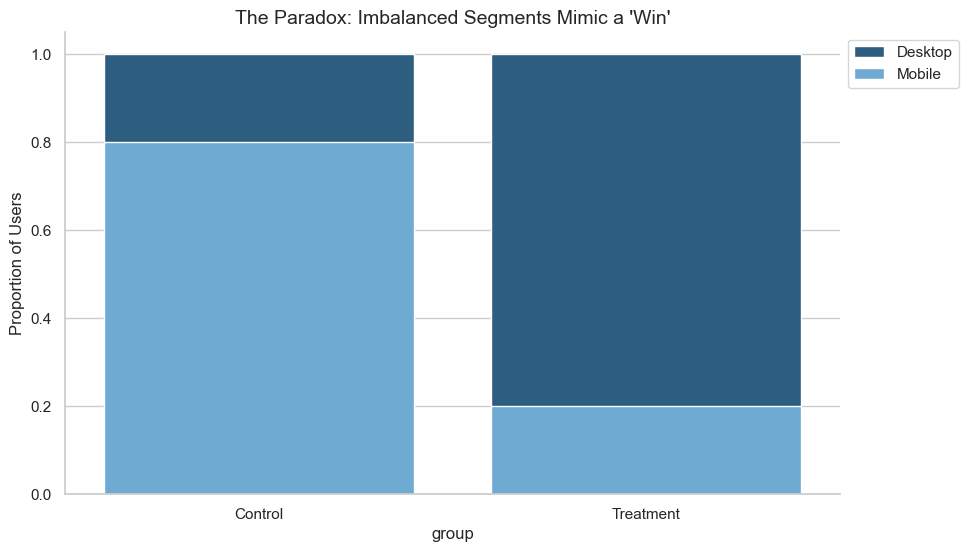

In [173]:
plt.figure(figsize=(10,6))

sns.barplot(x="group", y=[1,1], data=pivot_prop, color="#21618c", label="Desktop")
sns.barplot(x="group", y="Mobile", data=pivot_prop, color="#5dade2", label="Mobile")

plt.title("The Paradox: Imbalanced Segments Mimic a 'Win'", fontsize=14)
plt.ylabel("Proportion of Users")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
sns.despine()
plt.show()

In [53]:
# (d) riWte a 3-sentence explanation of what went wrong and how to avoid it in real experiments.
# The Treatment group's "win" was an illusion caused by Simpson's Paradox, where a lopsided mix of high-converting Desktop users inflated the results. 
# In reality, performance was identical in both segments, but the groups weren't balanced fairly. 
# To avoid this, use stratified randomization to balance key segments upfront or regression modeling to control for these factors during analysis.

# A one-liner to reveal the imbalance immediately
print(pd.crosstab(data['group'], data['segment'], values=data['users'], aggfunc='sum', normalize='index'))

segment    Desktop  Mobile
group                     
Control        0.2     0.8
Treatment      0.8     0.2


---

### Q3 — Novelty effect detection

```
Simulate an A/B test running for 21 days where treatment gets a novelty bump in week 1
# that decays back to baseline by week 3.
# Week 1: treatment CTR = 12% (novelty), control = 9%
# Week 2: treatment CTR = 10.5% (fading), control = 9%
# Week 3: treatment CTR = 9.2% (settled), control = 9%
# daily_n = 500 users per group per day
# (a) Plot daily conversion rates for both groups over 21 days.
# (b) Run a t-test using only week 1 data. Is it significant?
# (c) Run a t-test using only week 3 data. Is it significant?
# (d) What decision would you make, and why does experiment duration matter?
```


In [ ]:
# Q3: Novelty effect detection
# Chart + analysis woven together — visualize as you discover

Simulate an A/B test running for 21 days where treatment gets a novelty bump in week 1
# that decays back to baseline by week 3.
# Week 1: treatment CTR = 12% (novelty), control = 9%
# Week 2: treatment CTR = 10.5% (fading), control = 9%
# Week 3: treatment CTR = 9.2% (settled), control = 9%
# daily_n = 500 users per group per day
# (a) Plot daily conversion rates for both groups over 21 days.
# (b) Run a test using only week 1 data. Is it significant?
# (c) Run a test using only week 3 data. Is it significant?
# (d) What decision would you make, and why does experiment duration matter?

,Week,Group,CTR
0,1,Control,0.090
1,2,Control,0.090
2,3,Control,0.090
3,1,Treatment,0.120
4,2,Treatment,0.105
5,3,Treatment,0.092


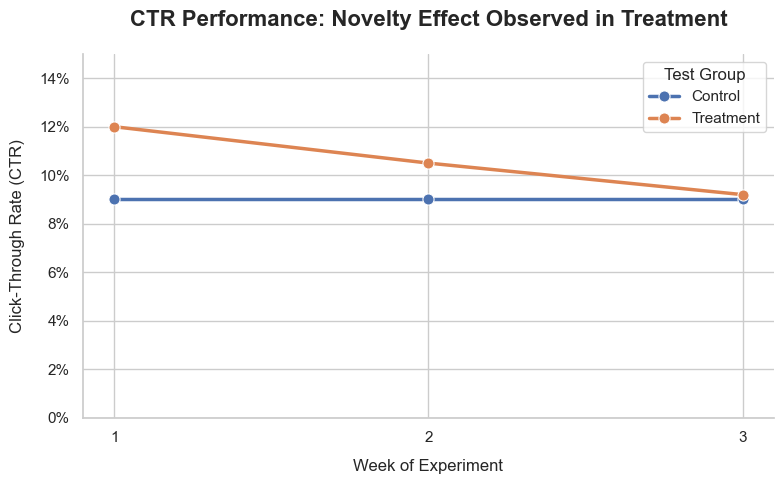

In [70]:
# (a) Plot daily conversion rates for both groups over 21 days.

# setup data
df = pd.DataFrame({
    'Week':     [1,2,3]*2,
    'Group':    ['Control']*3 + ['Treatment']*3,
    'CTR':      [.09, .09, .09, .12, .105, .092]
})
display(df)

# plotting
plt.figure(figsize=(8,5))

ax = sns.lineplot(data=df, x='Week', y='CTR', hue='Group', marker='o', markersize=8, linewidth=2.5)

plt.title('CTR Performance: Novelty Effect Observed in Treatment', pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Week of Experiment', labelpad=10)
plt.ylabel('Click-Through Rate (CTR)', labelpad=10)

plt.xticks([1, 2, 3])
plt.ylim(0,0.15)

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]) 

plt.legend(title='Test Group', frameon=True, facecolor='white')

# Tighten the layout
sns.despine() # Removes the top and right borders
plt.tight_layout()
plt.show()

In [ ]:
# (b) Run a test using only week 1 data. Is it significant?

from statsmodels.stats.proportion import proportions_ztest

counts = np.array([500*7*0.12, 500*7*0.09]).astype(int) # treatment goes first
nobs = np.array([500*7, 500*7])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')


p-value: 0.0000
Reject H0: treatment is significantly better


In [ ]:
# (c) Run a test using only week 3 data. Is it significant?

counts = np.array([500*7*0.092, 500*7*0.09]).astype(int) # treatment goes first
nobs = np.array([500*7, 500*7])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')


p-value: 0.3856
Fail to reject H0: no significant difference detected


```
# (d) What decision would you make, and why does experiment duration matter?
Based on the data, the decision should be to not launch the new feature (or at least pause and redesign).
While Week 1 showed a "highly significant" win, the performance decayed rapidly toward the Control level by Week 3. This indicates a Novelty Effect, where users interact with a feature simply because it's new, not because it's inherently better. Launching based on Week 1 data would likely lead to flat long-term performance and "metric creep," where you complicate the product without lasting value.

---

### Q4 — Bayesian A/B testing

```
Implement a Bayesian A/B test for the same data as Day 3A Q1:
# Control: 5200 users, 338 conversions. Treatment: 5200 users, 416 conversions.
# Prior: Beta(1,1) for both groups.
# (a) Plot posterior distributions for both groups on the same chart.
# (b) Compute P(treatment > control) using Monte Carlo sampling (100,000 samples).
# (c) Compute 95% credible interval for the lift (treatment rate - control rate).
# (d) Plot the distribution of sampled lifts with the credible interval shaded.
# (e) Compare to the frequentist result from Day 3A. Which is easier to explain
#     to a non-technical stakeholder?
```


In [ ]:
# Q4: Bayesian A/B testing
# Chart + analysis woven together — visualize as you discover

Implement a Bayesian A/B test for the same data as Day 3A Q1:
# Control: 5200 users, 338 conversions. Treatment: 5200 users, 416 conversions.
# Prior: Beta(1,1) for both groups.
# (a) Plot posterior distributions for both groups on the same chart.
# (b) Compute P(treatment > control) using Monte Carlo sampling (100,000 samples).
# (c) Compute 95% credible interval for the lift (treatment rate - control rate).
# (d) Plot the distribution of sampled lifts with the credible interval shaded.
# (e) Compare to the frequentist result from Day 3A. Which is easier to explain
#     to a non-technical stakeholder?

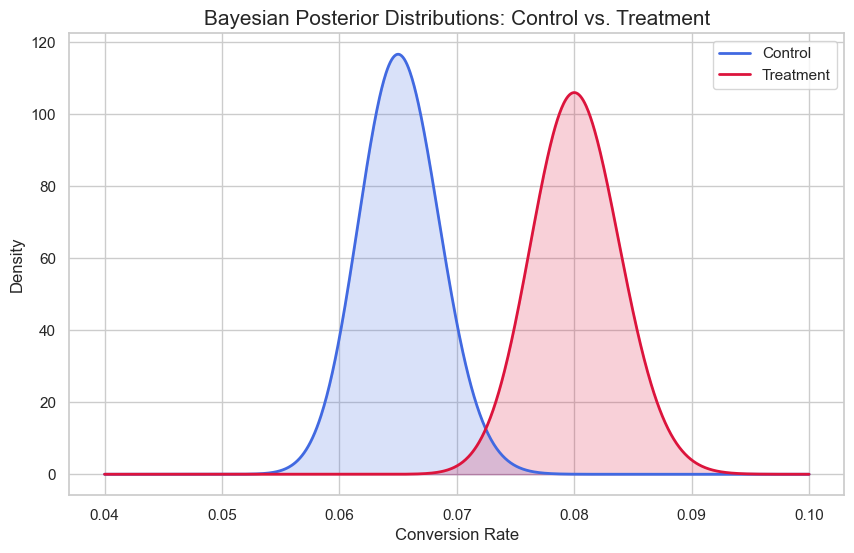

In [88]:

# (a) Plot posterior distributions for both groups on the same chart.

# setup data
n_ctrl, conv_ctrl = 5200, 338
n_trt,  conv_trt  = 5200, 416

# Posterior distributions: (Prior Beta(1,1) + Data)
ctrl_post = stats.beta(1 + conv_ctrl, 1 + (n_ctrl - conv_ctrl))
trt_post  = stats.beta(1 + conv_trt,  1 + (n_trt  - conv_trt))

# plotting
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

x = np.linspace(0.04, 0.10, 1000) # Range around the expected 6.5% and 8%

sns.lineplot(x=x, y=ctrl_post.pdf(x), label='Control', color='royalblue', lw=2)
plt.fill_between(x, ctrl_post.pdf(x), color='royalblue', alpha=0.2)

sns.lineplot(x=x, y=trt_post.pdf(x), label='Treatment', color='crimson', lw=2)
plt.fill_between(x, trt_post.pdf(x), color='crimson', alpha=0.2)

plt.title('Bayesian Posterior Distributions: Control vs. Treatment', fontsize=15)
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.legend()
plt.show()


In [91]:
# (b) Compute P(treatment > control) using Monte Carlo sampling (100,000 samples).
samples_ctrl = ctrl_post.rvs(100000)
samples_trt  = trt_post.rvs(100000)
prob_trt_better = (samples_trt > samples_ctrl).mean()
print(f'P(treatment > control): {prob_trt_better:.1%}')

P(treatment > control): 99.8%


In [101]:
# (c) Compute 95% credible interval for the lift (treatment rate - control rate).
lift_samples = samples_trt - samples_ctrl

lower, upper = np.percentile(lift_samples,[2.5, 97.5])
print(f"Mean Lift:   {np.mean(lift_samples):.2%}")
print(f"Median Lift: {np.median(lift_samples):.2%}")
print(f"We are 95% confident the lift will be between {lower:.1%} and {upper:.1%}.")

Mean Lift:   1.50%
Median Lift: 1.50%
We are 95% confident the lift will be between 0.5% and 2.5%.


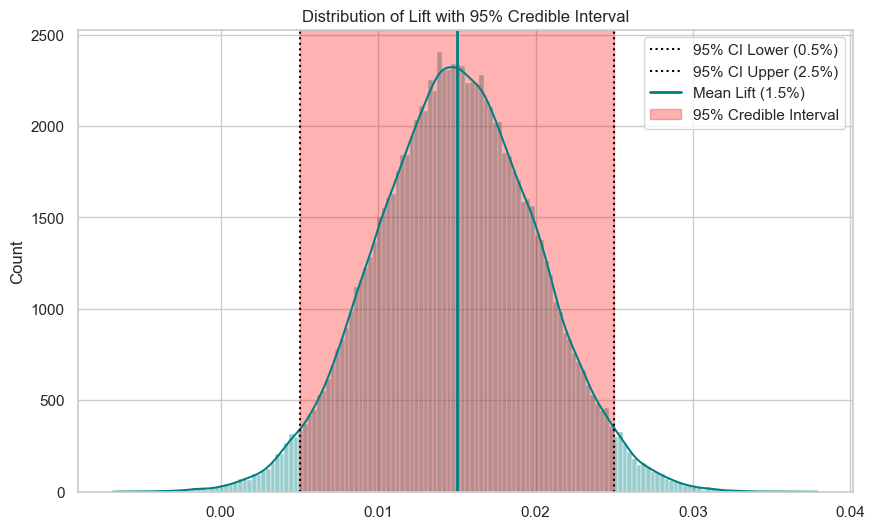

In [100]:
# (d) Plot the distribution of sampled lifts with the credible interval shaded.
plt.figure(figsize=(10, 6))
sns.histplot(lift_samples, color="teal", kde=True, alpha=0.4)


# Add the 95% Credible Interval lines
plt.axvline(lower, color='black', linestyle=':', label=f'95% CI Lower ({lower:.1%})')
plt.axvline(upper, color='black', linestyle=':', label=f'95% CI Upper ({upper:.1%})')

# Add a line for the Mean (Expected Value)
plt.axvline(lift_samples.mean(), color='teal', linewidth=2, label=f'Mean Lift ({lift_samples.mean():.1%})')

# shaded the credibel interval
plt.axvspan(lower, upper, alpha=0.3, color='red', label='95% Credible Interval')

plt.title("Distribution of Lift with 95% Credible Interval")
plt.legend()
plt.show()

```
# (e) Compare to the frequentist result from Day 3A. Which is easier to explain
#     to a non-technical stakeholder?

The Bayesian result is significantly easier to explain to a non-technical stakeholder because it speaks the language of probability and risk, whereas the Frequentist result speaks the language of math procedures.
There is a 99.8% chance that the new version is better. 
We expect a 1.5% absolute lift, and we are 95% sure the win will be at least 0.5%

---

### Q5 — Full A/B testing audit

```
You are given a 'completed' A/B test with the following characteristics:
# - Test ran for 4 days (stopped when p < 0.05 on day 4)
# - 8 metrics were tested, the one that was significant is being reported
# - Control group had 3200 users, treatment had 4100 users (unequal despite 50/50 split)
# - Relative lift reported as '35% improvement' (absolute lift: 0.7pp from 2% to 2.7%)
# - No pre-experiment power calculation was done
# (a) Simulate this scenario and demonstrate why each issue is a problem.
# (b) For the unequal groups: compute the sample ratio mismatch (SRM) and run a chi-squared test.
#     SRM is a sign that randomization is broken.
# (c) Apply multiple testing correction to the 8 metrics.
# (d) Write a structured audit report (as markdown cells) identifying each validity threat
#     and what the correct approach should have been.
# This is the most important practical skill in industry experimentation.
```


In [129]:
# Q5: Full A/B testing audit
# Chart + analysis woven together — visualize as you discover

In [106]:
# (a) Simulate this scenario and demonstrate why each issue is a problem.

# (a).1. the peeking issue

np.random.seed(420)
n_experiments = 1000
daily_n       = int((3200+4100)/(2*4))   # new users per day
days          = 4
alpha         = 0.05

false_positive_peeking  = 0
false_positive_fixed    = 0

for _ in range(n_experiments):
    ctrl_all = np.random.binomial(1, 0.10, daily_n * days)
    trt_all  = np.random.binomial(1, 0.10, daily_n * days)  # same rate!
    
    # Peeking: check every day, stop if significant
    peeked_significant = False
    for d in range(1, days + 1):
        c = ctrl_all[:d * daily_n]
        t = trt_all[:d * daily_n]
        _, p = stats.ttest_ind(c, t)
        if p < alpha:
            peeked_significant = True
            break
    if peeked_significant:
        false_positive_peeking += 1
    
    # Fixed horizon: only look at the end
    _, p_final = stats.ttest_ind(ctrl_all, trt_all)
    if p_final < alpha:
        false_positive_fixed += 1

print(f'False positive rate with peeking:      {false_positive_peeking/n_experiments:.1%}')
print(f'False positive rate with fixed horizon: {false_positive_fixed/n_experiments:.1%}')
print(f'Expected (alpha=0.05):                  5.0%')


False positive rate with peeking:      12.4%
False positive rate with fixed horizon: 3.6%
Expected (alpha=0.05):                  5.0%


In [110]:
# (a).2. The multiple comparison - cherry picking
sims = 1000
false_positive_experiments = 0

for _ in range(sims):
    # Check 8 metrics in one experiment
    p_vals = []
    for _ in range(8):
        # Using the prompt's N and 2% baseline for both (Null is true)
        ctrl = np.random.binomial(1, 0.02, 3200)
        trt  = np.random.binomial(1, 0.02, 4100)
        p_vals.append(stats.ttest_ind(ctrl, trt)[1])
    
    # If ANY of the 8 metrics hit p < 0.05, the experimenter reports a "win"
    if any(p < 0.05 for p in p_vals):
        false_positive_experiments += 1

print(f"Out of {sims} experiments with NO real effect:")
print(f"We found a 'significant' result {false_positive_experiments/sims:.1%} of the time.")


Out of 1000 experiments with NO real effect:
We found a 'significant' result 34.7% of the time.


In [116]:
# (a).3. The "Small Sample / Low Baseline" Trap
n_control   = 3200
n_treatment = 4100
conv_control   = 3200*0.02
conv_treatment = 4100*0.027

# Two-proportion z-test
counts = np.array([conv_treatment, conv_control])
nobs   = np.array([n_treatment, n_control])
z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')

rate_c = conv_control / n_control
rate_t = conv_treatment / n_treatment

print(f'Control rate:    {rate_c:.2%}')
print(f'Treatment rate:  {rate_t:.2%}')
print(f'Absolute lift:   {(rate_t - rate_c):.2%}')
print(f'Relative lift:   {(rate_t - rate_c)/rate_c:.1%}')
print(f'z-statistic:     {z_stat:.4f}')
print(f'p-value:         {p_value:.4f}')

if p_value < 0.05:
    print('Reject H0: treatment is significantly better')
else:
    print('Fail to reject H0: no significant difference detected')


Control rate:    2.00%
Treatment rate:  2.70%
Absolute lift:   0.70%
Relative lift:   35.0%
z-statistic:     1.9417
p-value:         0.0261
Reject H0: treatment is significantly better


In [115]:
# (b) The "Sample Ratio Mismatch" (SRM)

observed = [3200, 4100]
expected = [3650, 3650]


# Run the Goodness-of-Fit test, not confused with stats.chi2_contingency which is used to measure relationship
chi2, p = stats.chisquare(observed)

print(f'chi2={chi2:.2f}, p={p:.4f}')

# A p-value this small means the chance of getting a 3200/4100 split by "luck" is basically zero.
# This proves your randomization was broken.

chi2=110.96, p=0.0000


In [ ]:
# (c) Apply multiple testing correction to the 8 metrics
from statsmodels.stats.multitest import multipletests

#np.random.seed(420)

n_control   = 3200
n_treatment = 4100
conv_control   = 3200*0.02
conv_treatment = 4100*0.027
n_tests  = 8

# observed "winning" p-value
counts = np.array([conv_treatment, conv_control])
nobs   = np.array([n_treatment, n_control])
p_winner = proportions_ztest(counts, nobs, alternative='larger')[1]

# simulate 7 other metrics that are just noise (p-values from Uniform 0,1)

p_noise = np.random.uniform(0, 1, 7).tolist()

# combine them
p_values = [p_winner] + p_noise

print(f'Uncorrected significant results: {sum(p < 0.05 for p in p_values)}')
print(f'Expected false positives: {n_tests * 0.05:.1f}')

# Bonferroni correction (most conservative)
reject_bonf, p_bonf, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
print(f'After Bonferroni: {sum(reject_bonf)} significant')

Uncorrected significant results: 8
Expected false positives: 0.4
After Bonferroni: 0 significant


```
# (d) Write a structured audit report (as markdown cells) identifying each validity threat and what the correct approach should have been.
Summary of the "4-Day Disaster":

    Multiple Testing: the test proves the p-value was "fishing," not finding.
    Peeking: By stopping at Day 4, the team "hacked" the p-value before it could regress to the mean.
    SRM: The 3200/4100 split proves the "random" groups were fundamentally different people.
    Low Baseline: A 35% relative lift is just "noise" when we're only dealing with tiny absolute movements (0.7pp).

The Recommendation
To fix this in the future:

    Pick ONE primary metric before the test starts.
    Run a Power Analysis to set a fixed duration (don't stop early!).
    Monitor SRM daily and throw out any test that fails the split.

---

### Q6 — Chi squared test

```

Practice: Chi-squared test of independence + multi-segment correction
# (a) Simulate a 3x2 contingency table:
#     device_type (mobile / tablet / desktop) x conversion (yes / no)
#     mobile:  8000 users, 8% conversion
#     tablet:  3000 users, 15% conversion
#     desktop: 5000 users, 25% conversion
#     Build the observed frequency table as a numpy array.
#
# (b) Run stats.chi2_contingency(observed)
#     Print: chi2 statistic, p-value, degrees of freedom
#     Print the expected frequency table. Verify no expected cell < 5.
#
# (c) Compute Cramer’s V:
#     n = observed.sum()
#     V = np.sqrt(chi2 / (n * (min(observed.shape) - 1)))
#     Interpret the effect size.
#
# (d) Visualize as a side-by-side heatmap:
#     Left: observed counts. Right: expected counts.
#     Use a diverging colormap to show where observed >> expected.
```


In [174]:
# a. Simulate a 3x2 contigency table
df = pd.DataFrame({
    'Device': ['mobile', 'tablet', 'desktop'],
    'Yes': [8000*0.08, 3000*0.15, 5000*0.25],
    'No': [8000*.92, 3000*0.85, 5000*0.75]
})

df[['Yes','No']] = df[['Yes','No']].astype(int)
print(df)

    Device   Yes    No
0   mobile   640  7360
1   tablet   450  2550
2  desktop  1250  3750


In [175]:
# b. run stat.chi2_contigency (test of independence)
chi2, p, dof, expected = stats.chi2_contingency(df[['Yes','No']])
print(f'chi2={chi2:.2f}, p={p:.4f}, dof={dof}')
print()
print('This will be effectively 0.0000 (highly significant). This confirms that "Device" is a massive factor in conversion performance.')

expected_df = pd.DataFrame(
    expected, 
    index=df['Device'], 
    columns=['Expected_Yes', 'Expected_No']
)
print(expected_df.astype(int))
print()
print('Verify no expected cell less than 5')
print(expected_df.astype(int)<5)


chi2=712.59, p=0.0000, dof=2

This will be effectively 0.0000 (highly significant). This confirms that "Device" is a massive factor in conversion performance.
         Expected_Yes  Expected_No
Device                            
mobile           1170         6830
tablet            438         2561
desktop           731         4268

Verify no expected cell less than 5
         Expected_Yes  Expected_No
Device                            
mobile          False        False
tablet          False        False
desktop         False        False


In [176]:
# (c) Compute Cramer’s V:

observed = df[['Yes', 'No']]

n = observed.values.sum()
V = np.sqrt(chi2 / (n * (min(observed.shape) - 1)))

print(f"Cramer's V: {V:.4f}")

if V <= 0.1:
    print('Small association')
elif V <= 0.3:
    print('Medium association')
else:
    print('Large association')

Cramer's V: 0.2110
Medium association


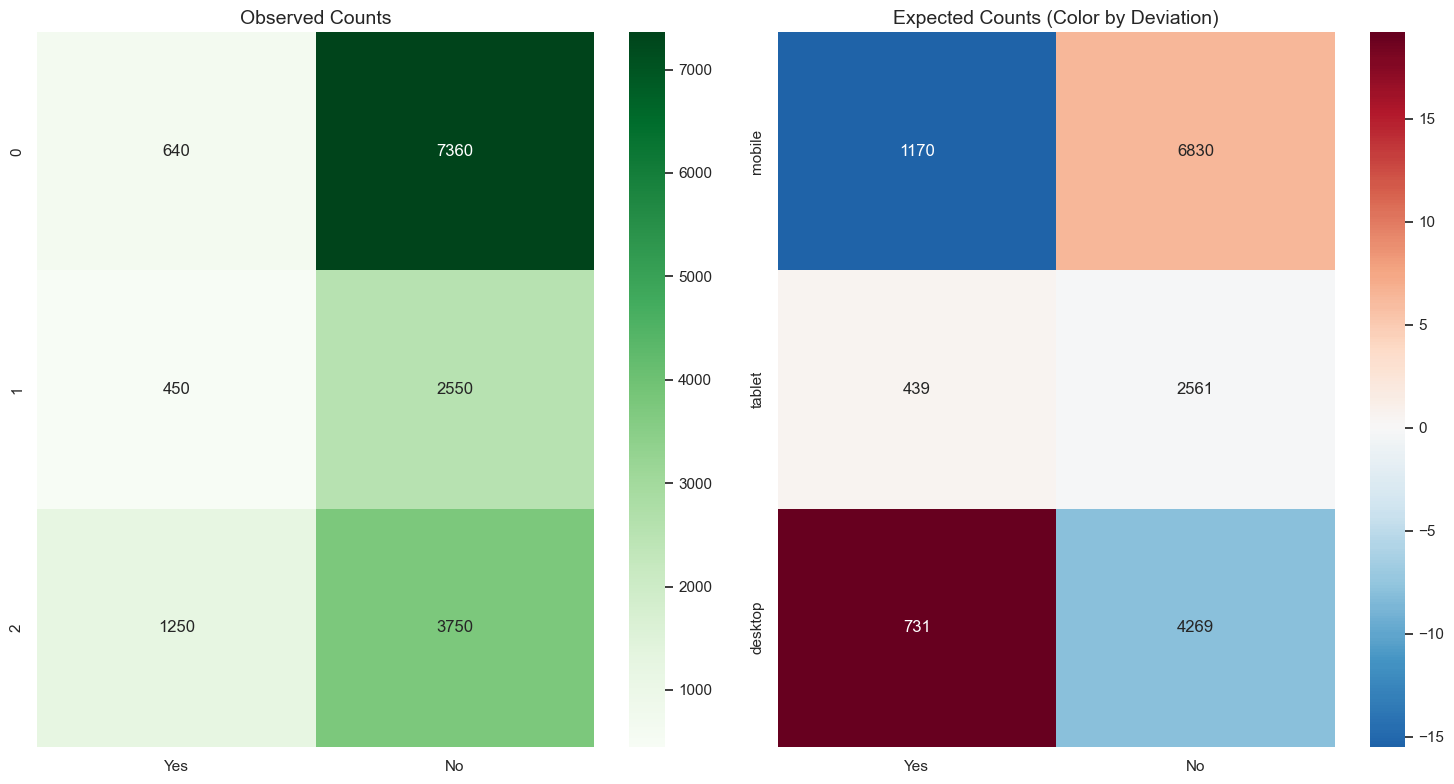

In [177]:
# (d) Visualize as a side-by-side heatmap:
#     Left: observed counts. Right: expected counts.
#     Use a diverging colormap to show where observed >> expected.

plt.figure(figsize=(15,8))

# Observed Counts (Perfect as is)
plt.subplot(1,2,1)
sns.heatmap(observed, annot=True, fmt="d", cmap="Greens", cbar=True)
plt.title("Observed Counts", fontsize=14)

# Expected Counts (Corrected for Deviation Coloring)
plt.subplot(1,2,2)
residuals = (observed.values - expected) / np.sqrt(expected)

# Note: We pass 'residuals' as the data to color the cells, 
# but pass 'expected' to 'annot' to show the raw numbers.
sns.heatmap(residuals, annot=expected, fmt=".0f", cmap="RdBu_r", center=0, yticklabels=df['Device'], xticklabels=['Yes', 'No'])

plt.title("Expected Counts (Color by Deviation)", fontsize=14)
plt.tight_layout()
plt.show()

```
Summary:
While Mobile has the highest volume, the heatmap reveals it is significantly underperforming its expected conversion potential (shown in deep blue). 
In contrast, Desktop is our strongest segment, converting way above its expected baseline (shown in deep red). 
This confirms that device type is a massive driver of conversion success and should be the primary focus for optimization efforts.